 DBSCAN Evaluation 
Silhouette Score (higher is better): 0.156
Davies-Bouldin Index (lower is better): 1.835
Calinski-Harabasz Index (higher is better): 141.725


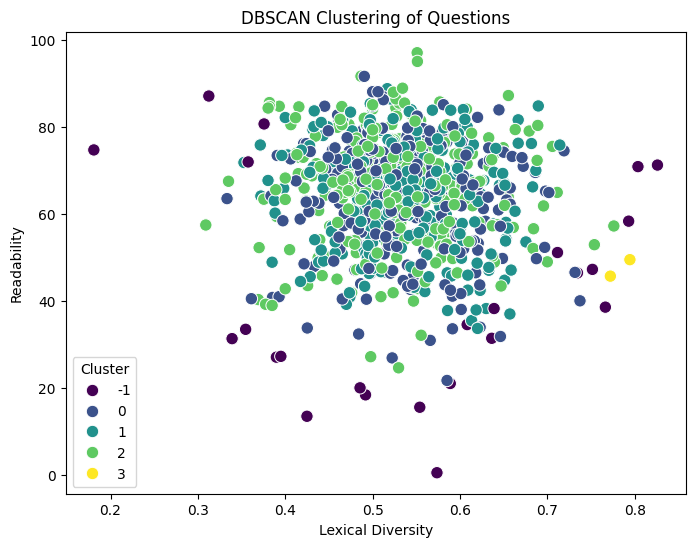

 DBSCAN clusters added and dataset saved.


In [1]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
import matplotlib.pyplot as plt
import seaborn as sns


# Load Dataset
df = pd.read_excel("ALL_with_features.xlsx")

#Handle Missing Values
numeric_cols = ['Lexical_Diversity', 'Avg_Sentence_Length', 'Readability', 'DoK_Level']
for col in numeric_cols:
    df[col] = df[col].fillna(df[col].mean())

# Feature Selection & Scaling
X = df[numeric_cols]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

#Train DBSCAN
dbscan = DBSCAN(eps=1.2, min_samples=5) 
labels = dbscan.fit_predict(X_scaled)
df['DBSCAN_Cluster'] = labels

# Evaluate DBSCAN
# DBSCAN may assign -1 as noise; filter those for metrics if needed
mask = labels != -1
if mask.sum() > 1:  # need at least 2 points for silhouette
    sil_score = silhouette_score(X_scaled[mask], labels[mask])
    db_score = davies_bouldin_score(X_scaled[mask], labels[mask])
    ch_score = calinski_harabasz_score(X_scaled[mask], labels[mask])
else:
    sil_score = db_score = ch_score = float('nan')

print(" DBSCAN Evaluation ")
print(f"Silhouette Score (higher is better): {sil_score:.3f}")
print(f"Davies-Bouldin Index (lower is better): {db_score:.3f}")
print(f"Calinski-Harabasz Index (higher is better): {ch_score:.3f}")

# Visualization

plt.figure(figsize=(8,6))
sns.scatterplot(
    x=df['Lexical_Diversity'],
    y=df['Readability'],
    hue=df['DBSCAN_Cluster'],
    palette='viridis',
    s=80
)
plt.title("DBSCAN Clustering of Questions")
plt.xlabel("Lexical Diversity")
plt.ylabel("Readability")
plt.legend(title="Cluster")
plt.show()

#Save Updated Dataset
df.to_excel("ALL_with_features.xlsx", index=False)
print(" DBSCAN clusters added and dataset saved.")

 Spectral Clustering Evaluation 
Silhouette Score (higher is better): 0.169
Davies-Bouldin Index (lower is better): 2.431
Calinski-Harabasz Index (higher is better): 171.864


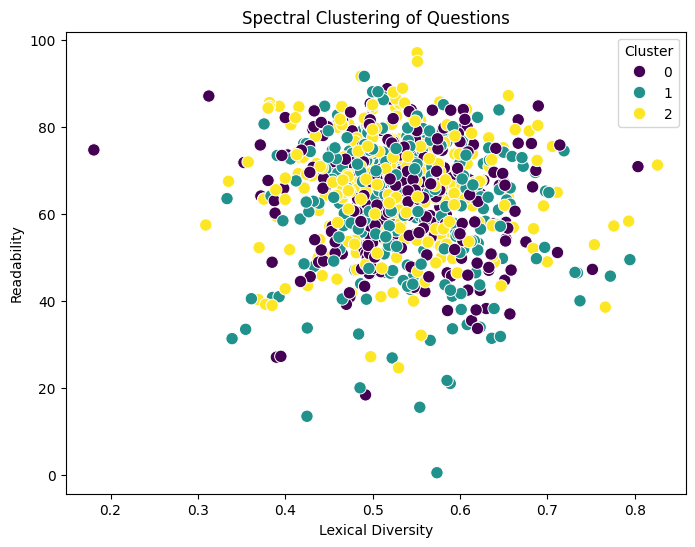

 Spectral clustering labels saved.


In [1]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import SpectralClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
import matplotlib.pyplot as plt
import seaborn as sns

#Load Dataset
df = pd.read_excel("ALL_with_features.xlsx")

#  Handle Missing Values
numeric_cols = ['Lexical_Diversity', 'Avg_Sentence_Length', 'Readability', 'DoK_Level']
for col in numeric_cols:
    df[col] = df[col].fillna(df[col].mean())

#  Feature Selection & Scaling
X = df[numeric_cols]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

#Build and Train Spectral Clustering
spectral = SpectralClustering(
    n_clusters=3,
    affinity='nearest_neighbors',
    n_neighbors=10,
    random_state=42
)
labels = spectral.fit_predict(X_scaled)
df['Spectral_Cluster'] = labels

# Evaluate Model
sil_score = silhouette_score(X_scaled, labels)
db_score = davies_bouldin_score(X_scaled, labels)
ch_score = calinski_harabasz_score(X_scaled, labels)

print(" Spectral Clustering Evaluation ")
print(f"Silhouette Score (higher is better): {sil_score:.3f}")
print(f"Davies-Bouldin Index (lower is better): {db_score:.3f}")
print(f"Calinski-Harabasz Index (higher is better): {ch_score:.3f}")

# Visualization
plt.figure(figsize=(8,6))
sns.scatterplot(
    x=df['Lexical_Diversity'],
    y=df['Readability'],
    hue=df['Spectral_Cluster'],
    palette='viridis',
    s=80
)
plt.title("Spectral Clustering of Questions")
plt.xlabel("Lexical Diversity")
plt.ylabel("Readability")
plt.legend(title="Cluster")
plt.show()

# Save Results
df.to_excel("ALL_with_features.xlsx", index=False)
print(" Spectral clustering labels saved.")

In [ ]:
from sklearn.cluster import DBSCAN, SpectralClustering
import joblib

# Create DBSCAN model
dbscan = DBSCAN(eps=0.5, min_samples=5)

# Train model
# dbscan.fit(X_scaled)

# Save DBSCAN model
joblib.dump(dbscan, "dbscan_model.pkl")

# Load DBSCAN model later
dbscan_loaded = joblib.load("dbscan_model.pkl")

# SPECTRAL CLUSTERING MODEL
# Create Spectral Clustering model
spectral_model = SpectralClustering(
    n_clusters=3,
    affinity='nearest_neighbors',
    n_neighbors=10,
    random_state=42
)

# Train model
# spectral_model.fit(X_scaled)

# Save Spectral model
joblib.dump(spectral_model, "spectral_model.pkl")

# Load Spectral model later
spectral_loaded = joblib.load("spectral_model.pkl")